In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

In [9]:
df = pd.read_excel("../data/Online Retail.xlsx")

print(df.shape)

df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [11]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
df = df.dropna(subset=["CustomerID"])

print(df.shape)

(406829, 8)


In [13]:
df = df[
    ~df["InvoiceNo"].astype(str).str.startswith("C")
]

print(df.shape)

(397924, 8)


In [14]:
df = df[df["Quantity"] > 0]

print(df.shape)

(397924, 8)


In [15]:
df = df[df["UnitPrice"] > 0]

print(df.shape)

(397884, 8)


In [16]:
print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Duplicate Rows: 5192


In [17]:
df = df.drop_duplicates()

print(df.shape)

(392692, 8)


In [18]:
df["Amount"] = (
    df["Quantity"] *
    df["UnitPrice"]
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [19]:
df["Amount"] = (
    df["Quantity"] *
    df["UnitPrice"]
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [20]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [21]:
snapshot_date = (
    df["InvoiceDate"].max() +
    pd.Timedelta(days=1)
)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [22]:
recency = (
    df.groupby("CustomerID")
      ["InvoiceDate"]
      .max()
      .reset_index()
)

recency.columns = [
    "CustomerID",
    "LastPurchaseDate"
]

recency["Recency"] = (
    snapshot_date -
    recency["LastPurchaseDate"]
).dt.days

recency.head()

,CustomerID,LastPurchaseDate,Recency
0,12346.0,2011-01-18 10:01:00,326
1,12347.0,2011-12-07 15:52:00,2
2,12348.0,2011-09-25 13:13:00,75
3,12349.0,2011-11-21 09:51:00,19
4,12350.0,2011-02-02 16:01:00,310


In [23]:
frequency = (
    df.groupby("CustomerID")
      ["InvoiceNo"]
      .nunique()
      .reset_index()
)

frequency.columns = [
    "CustomerID",
    "Frequency"
]

frequency.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [24]:
monetary = (
    df.groupby("CustomerID")
      ["Amount"]
      .sum()
      .reset_index()
)

monetary.columns = [
    "CustomerID",
    "Monetary"
]

monetary.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [25]:
rfm = recency.merge(
    frequency,
    on="CustomerID"
)

rfm = rfm.merge(
    monetary,
    on="CustomerID"
)

rfm.head()

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary
0,12346.0,2011-01-18 10:01:00,326,1,77183.60
1,12347.0,2011-12-07 15:52:00,2,7,4310.00
2,12348.0,2011-09-25 13:13:00,75,4,1797.24
3,12349.0,2011-11-21 09:51:00,19,1,1757.55
4,12350.0,2011-02-02 16:01:00,310,1,334.40


In [26]:
rfm = rfm[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary"
    ]
]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [27]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


In [28]:
rfm.isnull().sum()

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

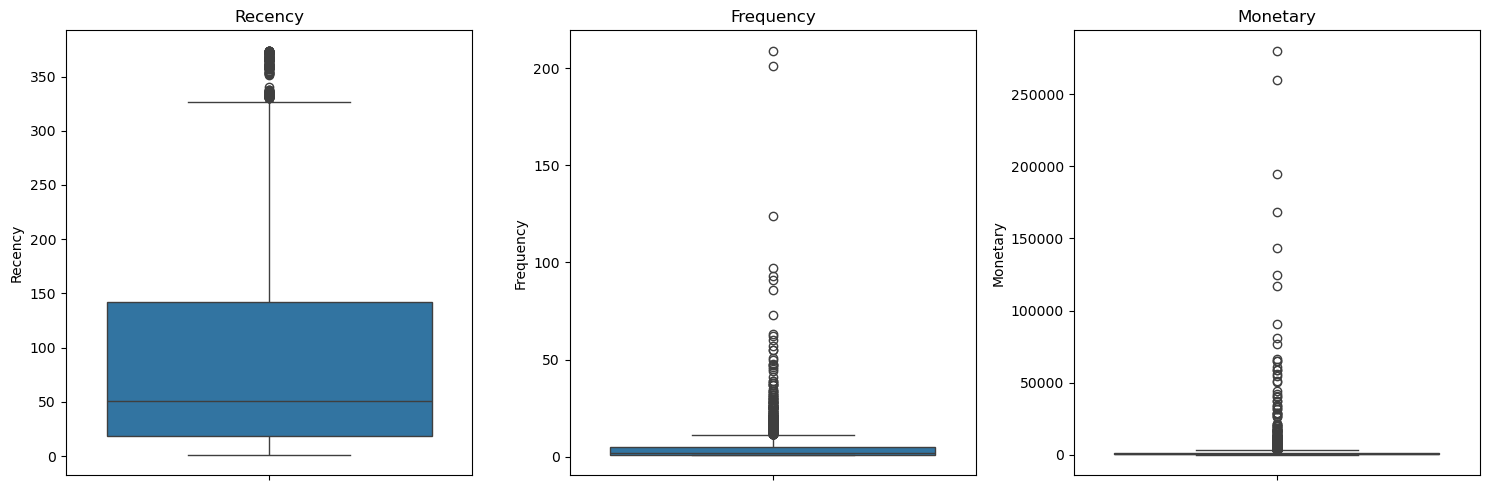

In [29]:
plt.figure(figsize=(15,5))

for i,col in enumerate(
    ["Recency","Frequency","Monetary"]
):

    plt.subplot(1,3,i+1)

    sns.boxplot(
        y=rfm[col]
    )

    plt.title(col)

plt.tight_layout()
plt.show()

In [30]:
for col in [
    "Recency",
    "Frequency",
    "Monetary"
]:

    Q1 = rfm[col].quantile(0.25)
    Q3 = rfm[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    rfm = rfm[
        (rfm[col] >= lower) &
        (rfm[col] <= upper)
    ]

rfm.shape

(3604, 4)

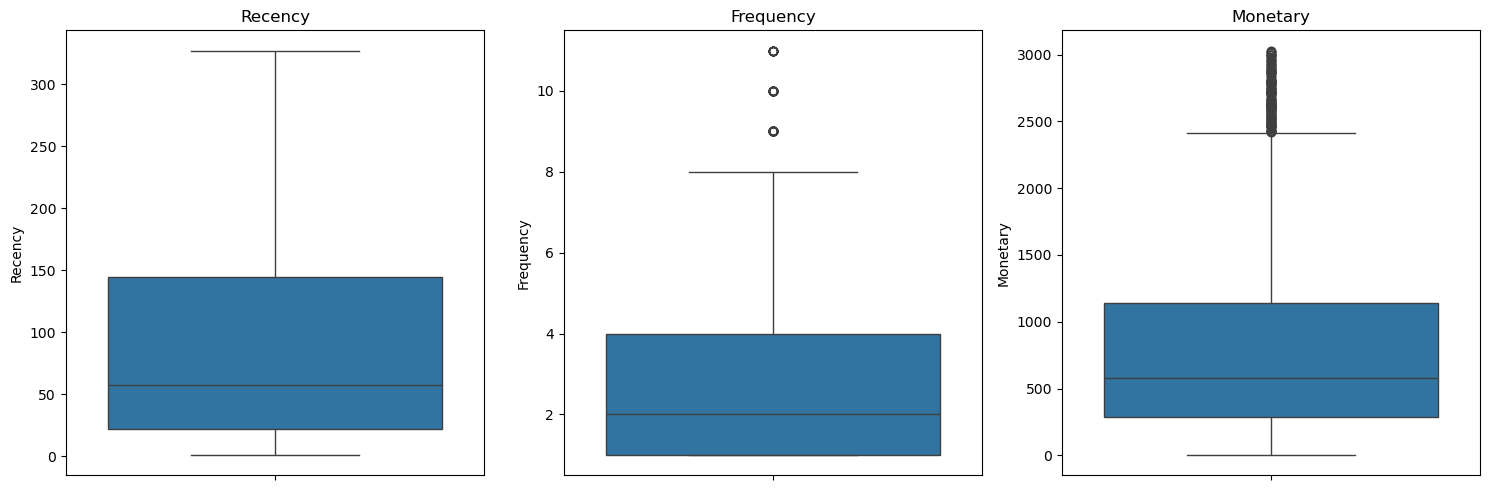

In [31]:
plt.figure(figsize=(15,5))

for i,col in enumerate(
    ["Recency","Frequency","Monetary"]
):

    plt.subplot(1,3,i+1)

    sns.boxplot(
        y=rfm[col]
    )

    plt.title(col)

plt.tight_layout()
plt.show()

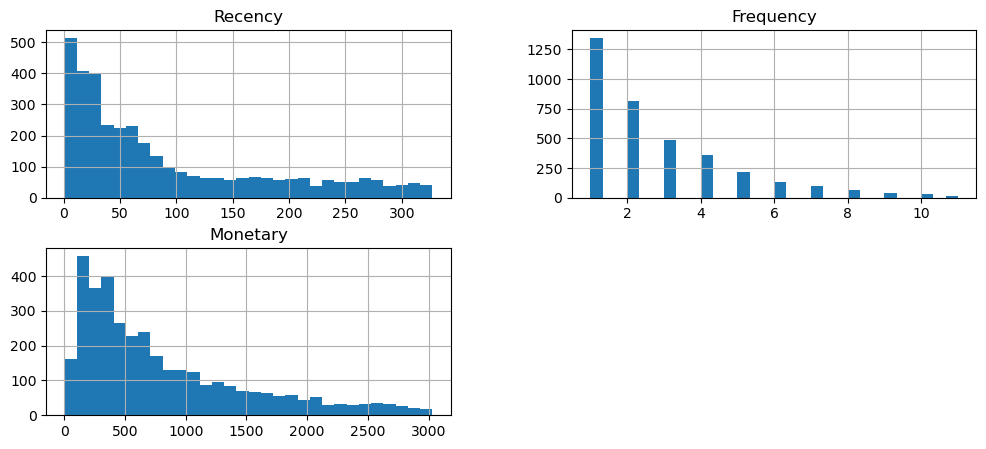

In [32]:
rfm[
    ["Recency","Frequency","Monetary"]
].hist(
    figsize=(12,5),
    bins=30
)

plt.show()

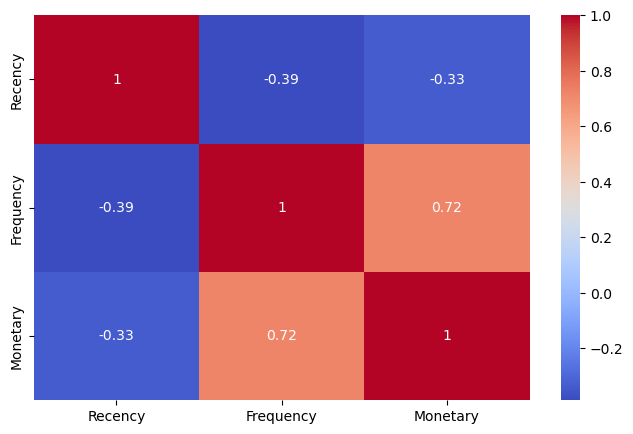

In [33]:
plt.figure(figsize=(8,5))

sns.heatmap(
    rfm[
        ["Recency",
         "Frequency",
         "Monetary"]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [34]:
X = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
]

X.head()

,Recency,Frequency,Monetary
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40
5,36,8,2506.04
6,204,1,89.00


In [35]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.18545429,  0.613312  ,  1.40888732],
       [-0.8114013 , -0.83012059,  1.35221668],
       [ 2.44128761, -0.83012059, -0.67980198],
       [-0.62138167,  2.53788879,  2.42093442],
       [ 1.25645935, -0.83012059, -1.03019188]])

In [36]:
rfm_cleaned = pd.DataFrame(
    X_scaled,
    columns=[
        "Recency",
        "Frequency",
        "Monetary"
    ]
)

rfm_cleaned.head()

,Recency,Frequency,Monetary
0,-0.185454,0.613312,1.408887
1,-0.811401,-0.830121,1.352217
2,2.441288,-0.830121,-0.679802
3,-0.621382,2.537889,2.420934
4,1.256459,-0.830121,-1.030192


In [37]:
rfm_cleaned.to_csv(
    "../data/retail_rfm_cleaned.csv",
    index=False
)

print(
    "retail_rfm_cleaned.csv saved successfully"
)

retail_rfm_cleaned.csv saved successfully


In [38]:
rfm_cleaned.shape

(3604, 3)